# Derivative-Free Stochastic Runge-Kutta Scheme for SDEs

## Problem

The Milstein scheme reaches strong order $1.0$ for a scalar Itô SDE
$dX_t = a(X_t,t)\,dt + b(X_t,t)\,dW_t$, but it needs the analytic derivative $b'(X_t,t)$ of the
diffusion coefficient. When $b$ is complicated, or only available numerically, that derivative is
inconvenient or expensive to obtain. A stochastic Runge-Kutta (SRK) scheme reaches the same strong
order $1.0$ by instead evaluating $b$ at a predicted supporting point, replacing the analytic
derivative with a finite-difference-like correction built entirely from function evaluations.


## Method

**Derivative-free strong order 1.0 scheme (Platen).** With time step $\Delta t$ and increment
$\Delta W_n \sim \mathcal{N}(0,\Delta t)$, first form a supporting value

$$
\bar{X}_n = X_n + a(X_n, t_n)\,\Delta t + b(X_n, t_n)\sqrt{\Delta t},
$$

then update

$$
X_{n+1} = X_n + a(X_n, t_n)\,\Delta t + b(X_n, t_n)\,\Delta W_n
        + \frac{1}{2\sqrt{\Delta t}}\Big[b(\bar{X}_n, t_n) - b(X_n, t_n)\Big]\big[(\Delta W_n)^2 - \Delta t\big].
$$

The bracketed finite difference $[b(\bar{X}_n) - b(X_n)]/\sqrt{\Delta t}$ plays the same role as
$b(X_n)b'(X_n)$ in the Milstein scheme — it is a one-sided difference quotient in the
$O(\sqrt{\Delta t})$ perturbation used to build $\bar{X}_n$ — without ever evaluating $b'$ directly.
This is the same convergence-order measurement technique used for the Milstein scheme: the same
underlying Brownian path is resolved at multiple step sizes by summing fine Wiener increments into
coarser ones, and the mean absolute error at the terminal time is checked for a $\Delta t^1$ slope
on a log-log plot.

**Example 1 — Geometric Brownian Motion**, compared directly against Euler-Maruyama (strong order
$0.5$) as a baseline, using the same setup as the Milstein notebook.

**Example 2 — a nonlinear SDE with an inconvenient diffusion derivative**:
$dX = -X\,dt + \dfrac{\sigma}{1+X^2}\,dW$. Its diffusion coefficient
$b(x) = \sigma/(1+x^2)$ has derivative $b'(x) = -2\sigma x/(1+x^2)^2$ — not hard here, but exactly
the kind of expression the derivative-free scheme avoids needing at all. With no closed-form
solution, the reference is a fine-grid simulation of the same scheme.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["grid.color"] = "0.85"
plt.rcParams["grid.linestyle"] = "-"


## Example 1: Geometric Brownian Motion — strong convergence order

Euler-Maruyama measured strong order: 0.490 (theory: 0.5)
SRK measured strong order:            1.002 (theory: 1.0)


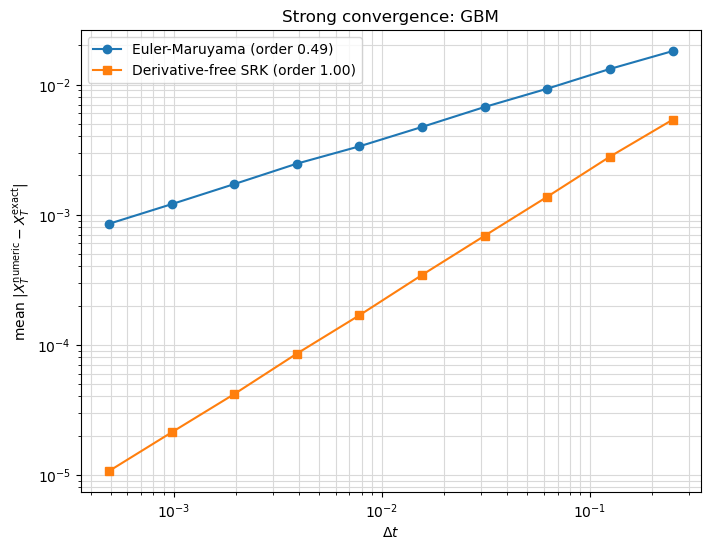

In [2]:
# GBM parameters (same as the Milstein notebook, for a direct comparison)
mu, sigma, X0, T = 0.08, 0.25, 1.0, 1.0

n_fine_pow = 12
N_fine = 2**n_fine_pow
dt_fine = T / N_fine
n_paths = 2000


def euler_maruyama_gbm(dW, dt):
    X = np.full(dW.shape[0], X0)
    for i in range(dW.shape[1]):
        X = X + mu * X * dt + sigma * X * dW[:, i]
    return X


def srk_gbm(dW, dt):
    X = np.full(dW.shape[0], X0)
    sqrt_dt = np.sqrt(dt)
    for i in range(dW.shape[1]):
        dWn = dW[:, i]
        X_bar = X + mu * X * dt + sigma * X * sqrt_dt
        X = X + mu * X * dt + sigma * X * dWn \
            + (sigma * X_bar - sigma * X) / (2 * sqrt_dt) * (dWn**2 - dt)
    return X


dW_fine = rng.normal(0.0, np.sqrt(dt_fine), size=(n_paths, N_fine))
W_T = dW_fine.sum(axis=1)
X_exact = X0 * np.exp((mu - 0.5 * sigma**2) * T + sigma * W_T)

levels = list(range(1, n_fine_pow - 1))
dts, em_errors, srk_errors = [], [], []
for k in levels:
    M = 2**k
    N_coarse = N_fine // M
    dt = dt_fine * M
    dW_coarse = dW_fine.reshape(n_paths, N_coarse, M).sum(axis=2)

    X_em = euler_maruyama_gbm(dW_coarse, dt)
    X_srk = srk_gbm(dW_coarse, dt)

    dts.append(dt)
    em_errors.append(np.mean(np.abs(X_em - X_exact)))
    srk_errors.append(np.mean(np.abs(X_srk - X_exact)))

dts = np.array(dts)
em_errors = np.array(em_errors)
srk_errors = np.array(srk_errors)

em_order = np.polyfit(np.log(dts), np.log(em_errors), 1)[0]
srk_order = np.polyfit(np.log(dts), np.log(srk_errors), 1)[0]

print(f"Euler-Maruyama measured strong order: {em_order:.3f} (theory: 0.5)")
print(f"SRK measured strong order:            {srk_order:.3f} (theory: 1.0)")

plt.figure(figsize=(8, 6))
plt.loglog(dts, em_errors, "o-", label=f"Euler-Maruyama (order {em_order:.2f})")
plt.loglog(dts, srk_errors, "s-", label=f"Derivative-free SRK (order {srk_order:.2f})")
plt.xlabel(r"$\Delta t$")
plt.ylabel(r"mean $|X_T^{\mathrm{numeric}} - X_T^{\mathrm{exact}}|$")
plt.title("Strong convergence: GBM")
plt.legend()
plt.grid(True, which="both")
plt.show()


## Example 2: A nonlinear SDE with an inconvenient diffusion derivative

Euler-Maruyama measured order (vs. fine reference): 0.554 (theory: 0.5)
SRK measured order (vs. fine reference):             1.067 (theory: 1.0)


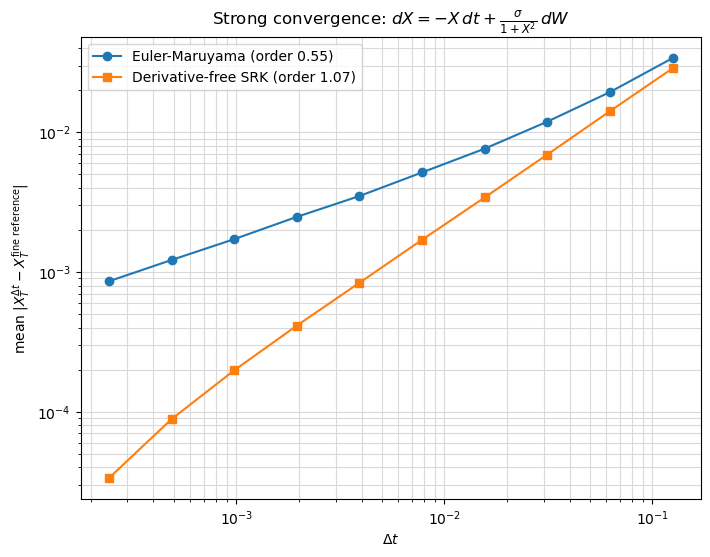

In [3]:
# dX = -X dt + sigma/(1+X^2) dW
sigma_nl, X0_nl, T_nl = 0.6, 1.0, 1.0


def a_nl(x):
    return -x


def b_nl(x):
    return sigma_nl / (1.0 + x**2)


def euler_maruyama_nl(dW, dt):
    X = np.full(dW.shape[0], X0_nl)
    for i in range(dW.shape[1]):
        X = X + a_nl(X) * dt + b_nl(X) * dW[:, i]
    return X


def srk_nl(dW, dt):
    X = np.full(dW.shape[0], X0_nl)
    sqrt_dt = np.sqrt(dt)
    for i in range(dW.shape[1]):
        dWn = dW[:, i]
        X_bar = X + a_nl(X) * dt + b_nl(X) * sqrt_dt
        X = X + a_nl(X) * dt + b_nl(X) * dWn \
            + (b_nl(X_bar) - b_nl(X)) / (2 * sqrt_dt) * (dWn**2 - dt)
    return X


n_fine_pow_nl = 13
N_fine_nl = 2**n_fine_pow_nl
dt_fine_nl = T_nl / N_fine_nl
n_paths_nl = 4000

dW_fine_nl = rng.normal(0.0, np.sqrt(dt_fine_nl), size=(n_paths_nl, N_fine_nl))
X_reference_nl = srk_nl(dW_fine_nl, dt_fine_nl)  # fine-grid SRK as reference "truth"

levels_nl = list(range(1, n_fine_pow_nl - 2))
dts_nl, em_errors_nl, srk_errors_nl = [], [], []
for k in levels_nl:
    M = 2**k
    N_coarse = N_fine_nl // M
    dt = dt_fine_nl * M
    dW_coarse = dW_fine_nl.reshape(n_paths_nl, N_coarse, M).sum(axis=2)
    X_em = euler_maruyama_nl(dW_coarse, dt)
    X_srk = srk_nl(dW_coarse, dt)
    dts_nl.append(dt)
    em_errors_nl.append(np.mean(np.abs(X_em - X_reference_nl)))
    srk_errors_nl.append(np.mean(np.abs(X_srk - X_reference_nl)))

# Drop the coarsest-vs-finest self-comparison bias isn't an issue here since the reference
# uses a much finer grid than any level tested; fit the order over all measured points.
dts_nl = np.array(dts_nl)
em_errors_nl = np.array(em_errors_nl)
srk_errors_nl = np.array(srk_errors_nl)

em_order_nl = np.polyfit(np.log(dts_nl[:-1]), np.log(em_errors_nl[:-1]), 1)[0]
srk_order_nl = np.polyfit(np.log(dts_nl[:-1]), np.log(srk_errors_nl[:-1]), 1)[0]

print(f"Euler-Maruyama measured order (vs. fine reference): {em_order_nl:.3f} (theory: 0.5)")
print(f"SRK measured order (vs. fine reference):             {srk_order_nl:.3f} (theory: 1.0)")

plt.figure(figsize=(8, 6))
plt.loglog(dts_nl, em_errors_nl, "o-", label=f"Euler-Maruyama (order {em_order_nl:.2f})")
plt.loglog(dts_nl, srk_errors_nl, "s-", label=f"Derivative-free SRK (order {srk_order_nl:.2f})")
plt.xlabel(r"$\Delta t$")
plt.ylabel(r"mean $|X_T^{\Delta t} - X_T^{\mathrm{fine\ reference}}|$")
plt.title(r"Strong convergence: $dX=-X\,dt+\frac{\sigma}{1+X^2}\,dW$")
plt.legend()
plt.grid(True, which="both")
plt.show()
